In [1]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import os

# Regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Classification for peak periods
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Optional preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# 2. LOAD CLEANED DATASET
folder = r"C:\Users\omars\Downloads"
file = "NYC_Taxi_Cleaned_Final_Version.csv"

# Read CSV
df = pd.read_csv(os.path.join(folder, file))
print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (8674609, 21)


In [4]:
print("Dataset shape (rows, columns):", df.shape)
df.head()

Dataset shape (rows, columns): (8674609, 21)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,source_month,pickup_hour,pickup_day,trip_duration
0,0,2.0,0.70,0,0,175,147,0,7.9,2.5,...,0.60,0.0,1.0,12.50,2.5,0.0,October,8,11,6.933333
1,1,1.0,0.81,0,0,175,233,0,6.5,0.0,...,2.10,0.0,1.0,12.60,2.5,0.0,October,8,11,4.333333
2,1,1.0,1.42,0,0,44,144,0,8.6,0.0,...,1.26,0.0,1.0,13.86,2.5,0.0,October,8,11,6.200000
3,1,1.0,0.90,0,0,139,68,0,7.9,0.0,...,2.38,0.0,1.0,14.28,2.5,0.0,October,8,11,7.050000
4,1,1.0,1.58,0,0,148,46,0,14.9,0.0,...,2.46,0.0,1.0,21.36,2.5,0.0,October,8,11,15.483333


In [5]:
# TAKE A SAMPLE (1.5m rows)
# -----------------------------
sample_df = df.sample(n=1500000, random_state=42)  # smaller dataset for faster training
print("Sampled dataset shape:", sample_df.shape)

Sampled dataset shape: (1500000, 21)


In [6]:
# 3. PREDICT FARE AMOUNT (REGRESSION)
# Target variable
target = "fare_amount"

X = sample_df.drop(columns=[target, "total_amount", "tip_amount", "congestion_surcharge", "Airport_fee", "pickup_hour"])
y = sample_df[target]

In [7]:
# 3.1 Encode categorical features
cat_cols = ["VendorID", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type", "source_month"]
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [8]:
# 3.2 Split dataset into training and test sets (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
# 3.3 Train Random Forest Regressor
regressor = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
regressor.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# 3.4 Predict on test set
y_pred = regressor.predict(X_test)

In [11]:
# 3.5 Evaluate regression model
print("---- Fare Amount Regression ----")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

---- Fare Amount Regression ----
R2 Score: 0.98242447040089
RMSE: 1.1100008815070996


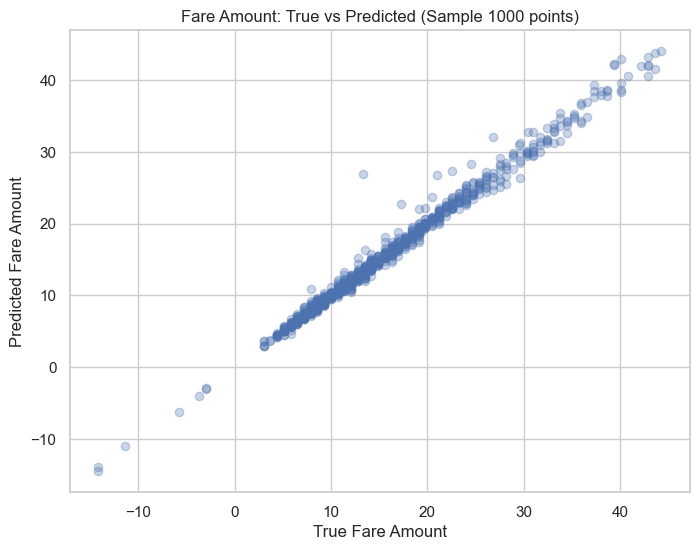

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Plot true vs predicted (first 1000 points)
plt.figure(figsize=(8,6))
plt.scatter(y_test[:1000], y_pred[:1000], alpha=0.3)
plt.xlabel("True Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Fare Amount: True vs Predicted (Sample 1000 points)")
plt.show()

In [14]:
# 5. PEAK FARE PERIODS CLASSIFICATION
sample_df["pickup_hour"] = sample_df["pickup_hour"].astype(int)

In [15]:
# Aggregate total fare per pickup hour to define peaks
hourly_fare = sample_df.groupby("pickup_hour")["fare_amount"].sum().reset_index()
threshold = hourly_fare["fare_amount"].quantile(0.75)
hourly_fare["peak"] = (hourly_fare["fare_amount"] >= threshold).astype(int)

In [16]:
# Merge peak info back to main dataframe
sample_df = sample_df.merge(hourly_fare[["pickup_hour", "peak"]], on="pickup_hour", how="left")

In [17]:
# Features (remove pickup_hour to avoid leakage)
X_peak = sample_df[["pickup_day", "trip_distance", "trip_duration", "VendorID", "RatecodeID", "passenger_count", "payment_type"]]
y_peak = sample_df["peak"]


In [18]:
# Encode categorical features
cat_cols_peak = ["VendorID", "RatecodeID", "payment_type"]
for col in cat_cols_peak:
    le = LabelEncoder()
    X_peak[col] = le.fit_transform(X_peak[col].astype(str))


C:\Users\omars\AppData\Local\Temp\ipykernel_1556\1827089472.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_peak[col] = le.fit_transform(X_peak[col].astype(str))
C:\Users\omars\AppData\Local\Temp\ipykernel_1556\1827089472.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_peak[col] = le.fit_transform(X_peak[col].astype(str))
C:\Users\omars\AppData\Local\Temp\ipykernel_1556\1827089472.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [19]:
# Train-test split
X_train_peak, X_test_peak, y_train_peak, y_test_peak = train_test_split(
    X_peak, y_peak, test_size=0.3, random_state=42
)

In [20]:
# Train Random Forest Classifier
classifier = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
classifier.fit(X_train_peak, y_train_peak)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# Predict
y_pred_peak = classifier.predict(X_test_peak)

# Evaluate
print("\n---- Peak Fare Period Classification ----")
print("Accuracy:", accuracy_score(y_test_peak, y_pred_peak))
print("\nClassification Report:\n", classification_report(y_test_peak, y_pred_peak))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_peak, y_pred_peak))


---- Peak Fare Period Classification ----
Accuracy: 0.5861288888888889

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.72      0.68    275941
           1       0.46      0.37      0.41    174059

    accuracy                           0.59    450000
   macro avg       0.55      0.55      0.55    450000
weighted avg       0.57      0.59      0.58    450000


Confusion Matrix:
 [[199046  76895]
 [109347  64712]]


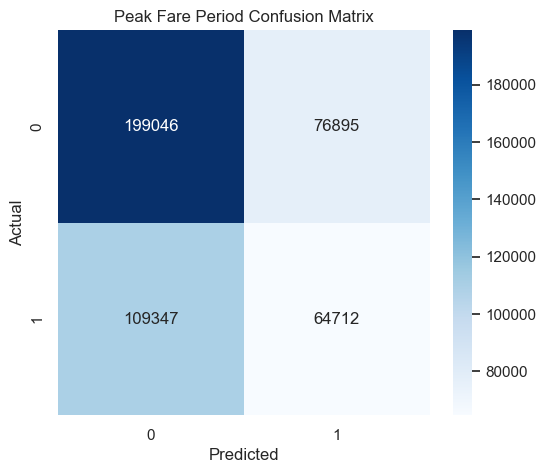

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test_peak, y_pred_peak)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Peak Fare Period Confusion Matrix")
plt.show()

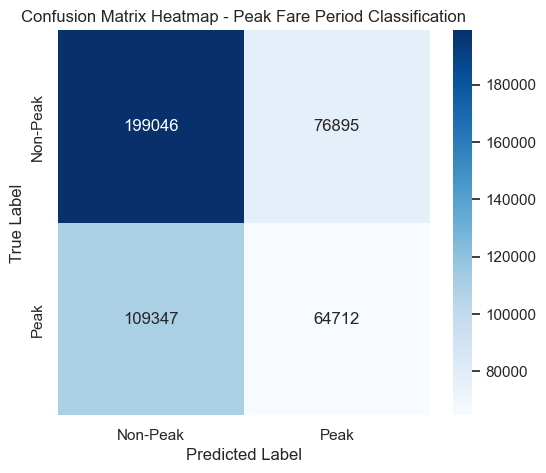

In [23]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_peak, y_pred_peak)

# Create a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Peak', 'Peak'], yticklabels=['Non-Peak', 'Peak'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap - Peak Fare Period Classification')
plt.show()
